<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/Diversificacion_Portafolio_Markowitz_BL_HRP_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diversificación de Portafolio: Markowitz, Black-Litterman y HRP (Árboles Jerárquicos)

**Notebook para clase — Teoría de portafolios con Python**

Construimos y comparamos portafolios óptimos con datos reales de mercado, cubriendo con **teoría matemática, ecuaciones, código, gráficas y tablas comparativas**:

| # | Método | Idea central |
|---|--------|--------------|
| 1 | **Markowitz (Media-Varianza)** | Frontera eficiente, máx. Sharpe, mín. varianza |
| 2 | **Black-Litterman** | Equilibrio de mercado + vistas del inversionista (Bayes) |
| 3 | **HRP — Hierarchical Risk Parity** | Árboles jerárquicos (clustering) sobre la matriz de correlación |
| 4 | Benchmarks: **Equal Weight (1/N)** y **Risk Parity** | Referencias ingenuas y de riesgo |

Al final: **backtest fuera de muestra** y tabla comparativa con retorno, volatilidad, Sharpe, drawdown y ratio de diversificación.

---

## 1. ¿Por qué diversificar? La matemática

Para un portafolio con pesos $\mathbf{w} = (w_1,\dots,w_N)^\top$, $\sum_i w_i = 1$, con retornos esperados $\boldsymbol{\mu}$ y matriz de covarianzas $\boldsymbol{\Sigma}$:

$$\mu_p = \mathbf{w}^\top\boldsymbol{\mu}, \qquad \sigma_p^2 = \mathbf{w}^\top\boldsymbol{\Sigma}\,\mathbf{w} = \sum_{i}\sum_{j} w_i w_j \sigma_i \sigma_j \rho_{ij}$$

**El milagro de la diversificación:** con $N$ activos equiponderados ($w_i = 1/N$), varianza individual promedio $\bar{\sigma}^2$ y covarianza promedio $\bar{\text{cov}}$:

$$\sigma_p^2 = \frac{1}{N}\bar{\sigma}^2 + \frac{N-1}{N}\,\overline{\text{cov}} \;\xrightarrow[N\to\infty]{}\; \overline{\text{cov}}$$

👉 El **riesgo idiosincrático** ($\bar\sigma^2/N$) se diversifica; el **riesgo sistemático** ($\overline{\text{cov}}$) no. La única "comida gratis" en finanzas es la correlación $\rho_{ij} < 1$.

In [1]:
# ==========================================================
# Librerías (en Colab, yfinance viene o se instala en segundos)
# ==========================================================
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 5)
np.random.seed(42)
print("Listo ✅")

Listo ✅


## 2. Datos: 10 acciones de distintos sectores (2018–2025)

Elegimos activos de sectores diversos (tecnología, salud, consumo, energía, financiero) precisamente para que la correlación imperfecta haga su trabajo. Dividimos:

- **In-sample (entrenamiento):** para estimar $\boldsymbol{\mu}$, $\boldsymbol{\Sigma}$ y optimizar pesos.
- **Out-of-sample (backtest):** último ~20% para evaluar honestamente (¡optimizar y evaluar en la misma muestra es hacer trampa!).

In [2]:
# ==========================================================
# Descarga de precios (con respaldo simulado por si falla la red)
# ==========================================================
TICKERS = ["AAPL", "MSFT", "JNJ", "PG", "XOM", "JPM", "KO", "NVDA", "WMT", "CAT"]

try:
    precios = yf.download(TICKERS, start="2018-01-01", end="2025-12-31",
                          auto_adjust=True, progress=False)["Close"].dropna()
    assert len(precios) > 500
    print("Datos reales descargados ✅")
except Exception as e:
    print("⚠️ Falló la descarga, generando datos simulados (GBM correlacionado)...")
    n_dias, n_act = 1800, len(TICKERS)
    L = np.linalg.cholesky(0.35*np.ones((n_act, n_act)) + 0.65*np.eye(n_act))
    mu_d = np.random.uniform(0.0002, 0.0009, n_act)
    sig_d = np.random.uniform(0.010, 0.028, n_act)
    Z = np.random.randn(n_dias, n_act) @ L.T
    rets_sim = mu_d + Z * sig_d
    precios = pd.DataFrame(100*np.exp(np.cumsum(rets_sim, axis=0)),
                           columns=TICKERS,
                           index=pd.bdate_range("2018-01-02", periods=n_dias))

# Retornos logarítmicos diarios: r_t = ln(P_t / P_{t-1})
retornos = np.log(precios / precios.shift(1)).dropna()

# Partición temporal 80/20
corte = int(len(retornos)*0.8)
ret_train, ret_test = retornos.iloc[:corte], retornos.iloc[corte:]
print(f"Train: {ret_train.index[0].date()} → {ret_train.index[-1].date()} ({len(ret_train)} días)")
print(f"Test : {ret_test.index[0].date()} → {ret_test.index[-1].date()} ({len(ret_test)} días)")

# Anualización (252 días bursátiles)
mu = ret_train.mean() * 252
Sigma = ret_train.cov() * 252
N = len(TICKERS)

Datos reales descargados ✅
Train: 2018-01-03 → 2024-05-22 (1607 días)
Test : 2024-05-23 → 2025-12-30 (402 días)


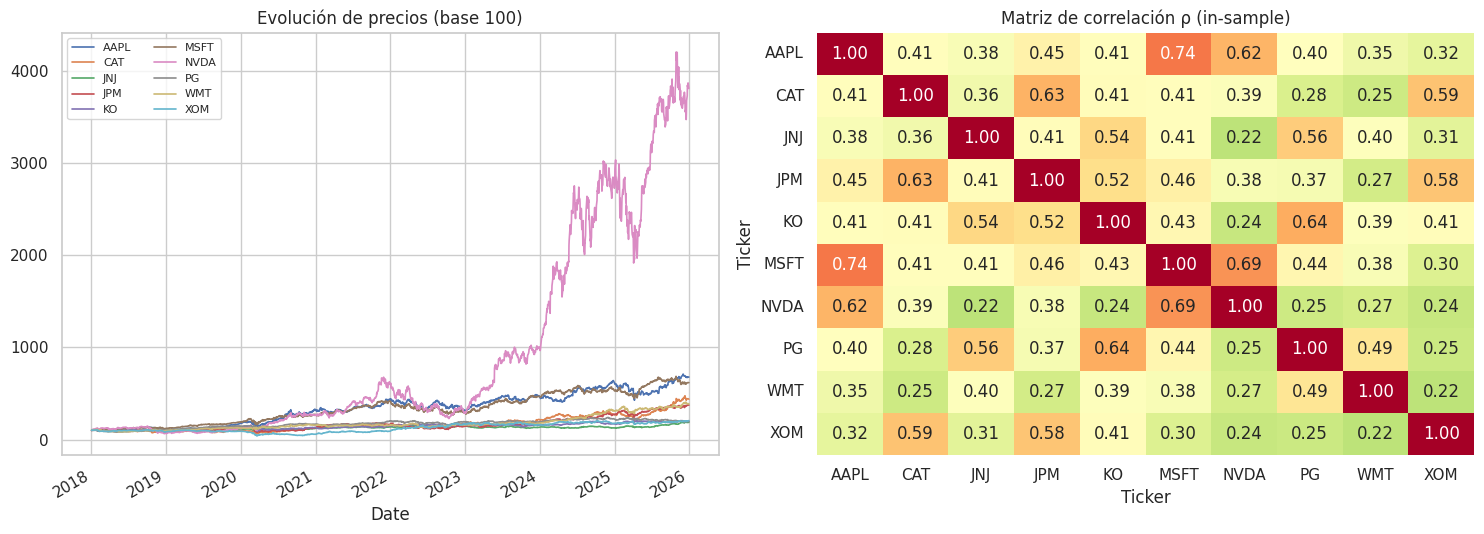

In [3]:
# Precios normalizados y matriz de correlación
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
(precios/precios.iloc[0]*100).plot(ax=axes[0], lw=1.2)
axes[0].set_title("Evolución de precios (base 100)"); axes[0].legend(ncol=2, fontsize=8)

sns.heatmap(ret_train.corr(), annot=True, fmt=".2f", cmap="RdYlGn_r",
            vmin=-0.2, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("Matriz de correlación ρ (in-sample)")
plt.tight_layout(); plt.show()

---
# 3. Markowitz: Optimización Media-Varianza (1952)

### Teoría

**Problema fundamental** (Markowitz, Premio Nobel 1990): para un nivel de retorno objetivo $\mu^*$, minimizar la varianza:

$$\min_{\mathbf{w}}\;\; \mathbf{w}^\top\boldsymbol{\Sigma}\,\mathbf{w} \quad \text{s.a.}\quad \mathbf{w}^\top\boldsymbol{\mu} = \mu^*, \quad \mathbf{w}^\top\mathbf{1} = 1 \;\;(\text{y } w_i \ge 0 \text{ sin ventas en corto})$$

El conjunto de soluciones al variar $\mu^*$ traza la **frontera eficiente**. Sin restricción de no-negatividad tiene solución analítica (multiplicadores de Lagrange):

$$\mathcal{L} = \mathbf{w}^\top\boldsymbol{\Sigma}\mathbf{w} - \lambda_1(\mathbf{w}^\top\boldsymbol{\mu} - \mu^*) - \lambda_2(\mathbf{w}^\top\mathbf{1} - 1) \;\Rightarrow\; \mathbf{w}^* = \boldsymbol{\Sigma}^{-1}(\lambda_1\boldsymbol{\mu} + \lambda_2\mathbf{1})/2$$

**Portafolio de mínima varianza global (GMV):**
$$\mathbf{w}_{GMV} = \frac{\boldsymbol{\Sigma}^{-1}\mathbf{1}}{\mathbf{1}^\top\boldsymbol{\Sigma}^{-1}\mathbf{1}}$$

**Portafolio tangente (máximo Sharpe):** con tasa libre de riesgo $r_f$, maximiza el **ratio de Sharpe**
$$SR = \frac{\mu_p - r_f}{\sigma_p}, \qquad \mathbf{w}_{tan} \propto \boldsymbol{\Sigma}^{-1}(\boldsymbol{\mu} - r_f\mathbf{1})$$

La recta que une $r_f$ con el portafolio tangente es la **Línea del Mercado de Capitales (CML)**:
$$\mu_p = r_f + \frac{\mu_{tan}-r_f}{\sigma_{tan}}\,\sigma_p$$

**Crítica clave (motiva Black-Litterman):** los pesos óptimos son hipersensibles a $\boldsymbol{\mu}$ — errores pequeños de estimación producen portafolios extremos y concentrados ("error maximizers", Michaud 1989).

In [4]:
# ==========================================================
# Simulación Monte Carlo: 20,000 portafolios aleatorios
# ==========================================================
rf = 0.03  # tasa libre de riesgo anual

def port_stats(w, mu=mu, Sigma=Sigma):
    r = w @ mu
    s = np.sqrt(w @ Sigma @ w)
    return r, s, (r - rf)/s

W_sim = np.random.dirichlet(np.ones(N), 20000)
stats_sim = np.array([port_stats(w) for w in W_sim])

# ==========================================================
# Optimización numérica (scipy) con restricción long-only
# ==========================================================
cons = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
bnds = [(0, 1)]*N
w0 = np.ones(N)/N

# Mínima varianza global
w_gmv = minimize(lambda w: w @ Sigma @ w, w0, bounds=bnds, constraints=cons).x

# Máximo Sharpe (minimizamos el negativo)
w_tan = minimize(lambda w: -port_stats(w)[2], w0, bounds=bnds, constraints=cons).x

# Frontera eficiente: barrido de retornos objetivo
frontera = []
for mu_obj in np.linspace(port_stats(w_gmv)[0], mu.max()*0.99, 60):
    c2 = cons + [{"type": "eq", "fun": lambda w, m=mu_obj: w @ mu - m}]
    res = minimize(lambda w: w @ Sigma @ w, w0, bounds=bnds, constraints=c2)
    frontera.append((mu_obj, np.sqrt(res.fun)))
frontera = np.array(frontera)

r_g, s_g, _ = port_stats(w_gmv)
r_t, s_t, sr_t = port_stats(w_tan)
print(f"GMV     → μ={r_g:.2%}, σ={s_g:.2%}")
print(f"Tangente→ μ={r_t:.2%}, σ={s_t:.2%}, Sharpe={sr_t:.2f}")

GMV     → μ=9.17%, σ=16.11%
Tangente→ μ=28.65%, σ=28.14%, Sharpe=0.91


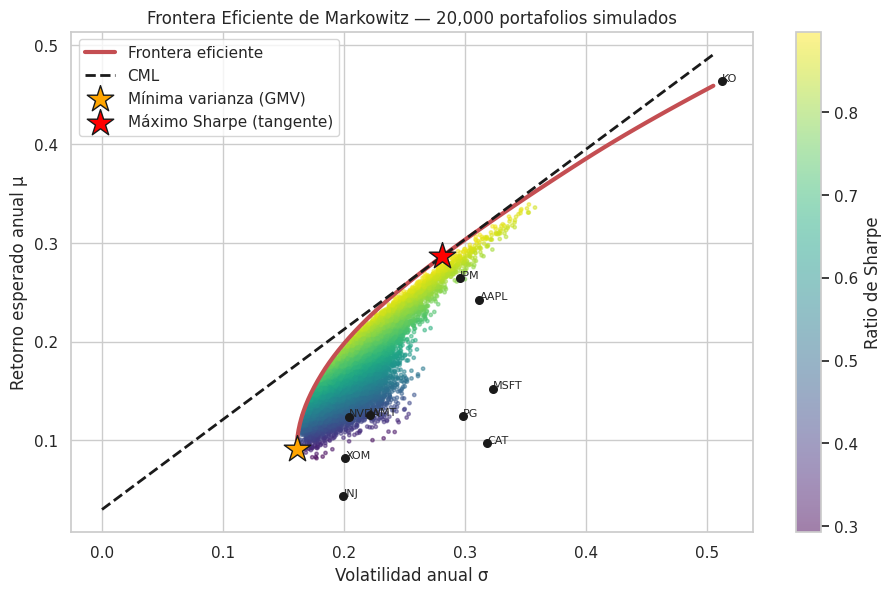

In [5]:
# ==========================================================
# Gráfica: frontera eficiente, nube Monte Carlo y CML
# ==========================================================
plt.figure(figsize=(11, 6.5))
sc = plt.scatter(stats_sim[:,1], stats_sim[:,0], c=stats_sim[:,2], s=6,
                 cmap="viridis", alpha=0.5)
plt.colorbar(sc, label="Ratio de Sharpe")
plt.plot(frontera[:,1], frontera[:,0], "r-", lw=3, label="Frontera eficiente")

x_cml = np.linspace(0, frontera[:,1].max(), 50)
plt.plot(x_cml, rf + (r_t-rf)/s_t * x_cml, "k--", lw=2, label="CML")
plt.scatter([s_g], [r_g], marker="*", s=400, c="orange", edgecolors="k",
            zorder=5, label="Mínima varianza (GMV)")
plt.scatter([s_t], [r_t], marker="*", s=400, c="red", edgecolors="k",
            zorder=5, label="Máximo Sharpe (tangente)")
for i, t in enumerate(TICKERS):
    plt.annotate(t, (np.sqrt(Sigma.iloc[i,i]), mu.iloc[i]), fontsize=8)
plt.scatter(np.sqrt(np.diag(Sigma)), mu, c="k", s=30, zorder=4)
plt.xlabel("Volatilidad anual σ"); plt.ylabel("Retorno esperado anual μ")
plt.title("Frontera Eficiente de Markowitz — 20,000 portafolios simulados")
plt.legend(); plt.show()

---
# 4. Black-Litterman (Goldman Sachs, 1992)

### Teoría

Resuelve el problema de Markowitz de "basura entra, basura sale" combinando **dos fuentes de información** vía inferencia bayesiana:

**Paso 1 — El prior: retornos implícitos de equilibrio.** Si el mercado está en equilibrio (CAPM), los pesos de capitalización $\mathbf{w}_{mkt}$ ya son óptimos. Invertimos la optimización (*reverse optimization*):

$$\boldsymbol{\pi} = \delta\,\boldsymbol{\Sigma}\,\mathbf{w}_{mkt}$$

donde $\delta = \dfrac{\mu_{mkt}-r_f}{\sigma_{mkt}^2}$ es el coeficiente de aversión al riesgo del mercado. La distribución prior es $\;\boldsymbol{\mu} \sim \mathcal{N}(\boldsymbol{\pi}, \tau\boldsymbol{\Sigma})$, con $\tau$ pequeño (≈ 0.025–0.05).

**Paso 2 — Las vistas del inversionista.** Se expresan como $K$ afirmaciones lineales:

$$\mathbf{P}\,\boldsymbol{\mu} = \mathbf{Q} + \boldsymbol{\varepsilon}, \qquad \boldsymbol{\varepsilon}\sim\mathcal{N}(\mathbf{0},\boldsymbol{\Omega})$$

- $\mathbf{P}$ ($K\times N$): qué activos involucra cada vista.
- $\mathbf{Q}$ ($K\times 1$): el retorno que la vista predice.
- $\boldsymbol{\Omega}$: incertidumbre de cada vista (diagonal; típicamente $\Omega = \text{diag}(\mathbf{P}\,\tau\boldsymbol{\Sigma}\,\mathbf{P}^\top)$).

**Paso 3 — Posterior (Teorema de Bayes / mínimos cuadrados generalizados):**

$$\boxed{\;\boldsymbol{\mu}_{BL} = \Big[(\tau\boldsymbol{\Sigma})^{-1} + \mathbf{P}^\top\boldsymbol{\Omega}^{-1}\mathbf{P}\Big]^{-1}\Big[(\tau\boldsymbol{\Sigma})^{-1}\boldsymbol{\pi} + \mathbf{P}^\top\boldsymbol{\Omega}^{-1}\mathbf{Q}\Big]\;}$$

Es un **promedio ponderado por precisión** entre el equilibrio $\boldsymbol{\pi}$ y las vistas $\mathbf{Q}$: si una vista es muy incierta ($\Omega$ grande), el posterior se queda cerca del equilibrio. Luego se optimiza Markowitz con $\boldsymbol{\mu}_{BL}$:

$$\mathbf{w}_{BL} = \frac{1}{\delta}\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}_{BL} \quad (\text{o con restricciones, vía scipy})$$

**Resultado:** pesos estables, diversificados e intuitivos, que se desvían del mercado *solo* donde el inversionista tiene opiniones.

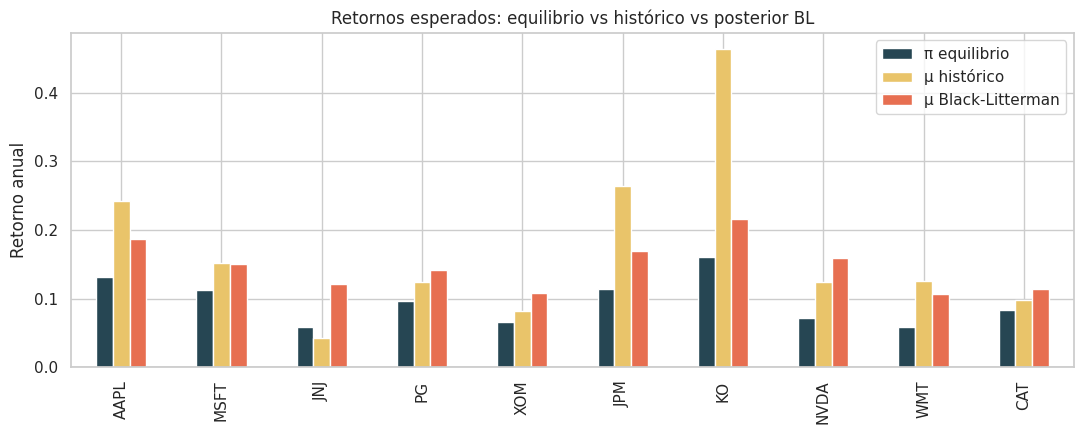

In [6]:
# ==========================================================
# Black-Litterman paso a paso
# ==========================================================
# Proxy de pesos de mercado: capitalización aproximada vía volumen*precio
# (para la clase usamos pesos iguales suavizados como w_mkt de juguete si no hay market caps)
try:
    caps = yf.download(TICKERS, period="5d", progress=False, auto_adjust=True)["Close"].iloc[-1]
    mktcaps = pd.Series({t: yf.Ticker(t).fast_info.get("marketCap", np.nan) for t in TICKERS})
    w_mkt = (mktcaps / mktcaps.sum()).fillna(1/N).values
except Exception:
    w_mkt = np.ones(N)/N
w_mkt = w_mkt / w_mkt.sum()

delta = 2.5      # aversión al riesgo típica del mercado
tau   = 0.05

# --- Paso 1: retornos implícitos de equilibrio
pi = delta * Sigma.values @ w_mkt

# --- Paso 2: vistas del inversionista (K = 2)
# Vista 1 (absoluta): NVDA rendirá 25% anual
# Vista 2 (relativa): JNJ superará a XOM por 4% anual
P = np.zeros((2, N))
P[0, TICKERS.index("NVDA")] = 1
P[1, TICKERS.index("JNJ")]  = 1
P[1, TICKERS.index("XOM")]  = -1
Q = np.array([0.25, 0.04])
Omega = np.diag(np.diag(P @ (tau*Sigma.values) @ P.T))

# --- Paso 3: posterior de Black-Litterman
inv_tS = np.linalg.inv(tau*Sigma.values)
inv_Om = np.linalg.inv(Omega)
mu_BL = np.linalg.inv(inv_tS + P.T @ inv_Om @ P) @ (inv_tS @ pi + P.T @ inv_Om @ Q)
mu_BL = pd.Series(mu_BL, index=TICKERS)

# Optimización long-only con μ_BL
w_bl = minimize(lambda w: -( (w @ mu_BL - rf) / np.sqrt(w @ Sigma @ w) ),
                w0, bounds=bnds, constraints=cons).x

comp = pd.DataFrame({"π equilibrio": pi, "μ histórico": mu.values, "μ Black-Litterman": mu_BL.values},
                    index=TICKERS)
comp.plot(kind="bar", figsize=(11, 4.5), color=["#264653", "#e9c46a", "#e76f51"])
plt.title("Retornos esperados: equilibrio vs histórico vs posterior BL")
plt.ylabel("Retorno anual"); plt.axhline(0, c="k", lw=0.8); plt.tight_layout(); plt.show()

---
# 5. HRP: Hierarchical Risk Parity — Árboles Jerárquicos (López de Prado, 2016)

### Teoría

Markowitz requiere **invertir $\boldsymbol{\Sigma}$**, lo cual es numéricamente inestable cuando hay activos muy correlacionados (número de condición alto → pesos explosivos). HRP evita la inversión usando **machine learning: clustering jerárquico (árboles)** en 3 pasos:

**Paso 1 — Árbol de clusters.** Convertimos correlaciones en **distancias métricas**:

$$d_{ij} = \sqrt{\tfrac{1}{2}\big(1 - \rho_{ij}\big)} \;\in [0, 1]$$

y construimos el **dendrograma** con enlace simple/ward: los activos que se mueven juntos quedan en la misma rama del árbol.

**Paso 2 — Cuasi-diagonalización.** Reordenamos filas/columnas de $\boldsymbol{\Sigma}$ según las hojas del árbol → los valores grandes quedan cerca de la diagonal (activos similares quedan adyacentes).

**Paso 3 — Bisección recursiva.** Bajamos por el árbol partiendo el portafolio en dos ramas y asignando capital **inversamente proporcional a la varianza** de cada rama:

$$\alpha_1 = 1 - \frac{\sigma_1^2}{\sigma_1^2 + \sigma_2^2}, \qquad \alpha_2 = 1 - \alpha_1$$

donde la varianza de cada cluster se calcula con pesos de varianza inversa: $\tilde{w}_i \propto 1/\Sigma_{ii}$, $\;\sigma_c^2 = \tilde{\mathbf{w}}^\top\boldsymbol{\Sigma}_c\,\tilde{\mathbf{w}}$.

**Ventajas:** no invierte $\boldsymbol{\Sigma}$, no necesita $\boldsymbol{\mu}$ (¡el input más ruidoso!), y De Prado muestra que **gana out-of-sample** a Markowitz en simulaciones Monte Carlo. Es el punto de encuentro entre finanzas y árboles de ML. 🌳

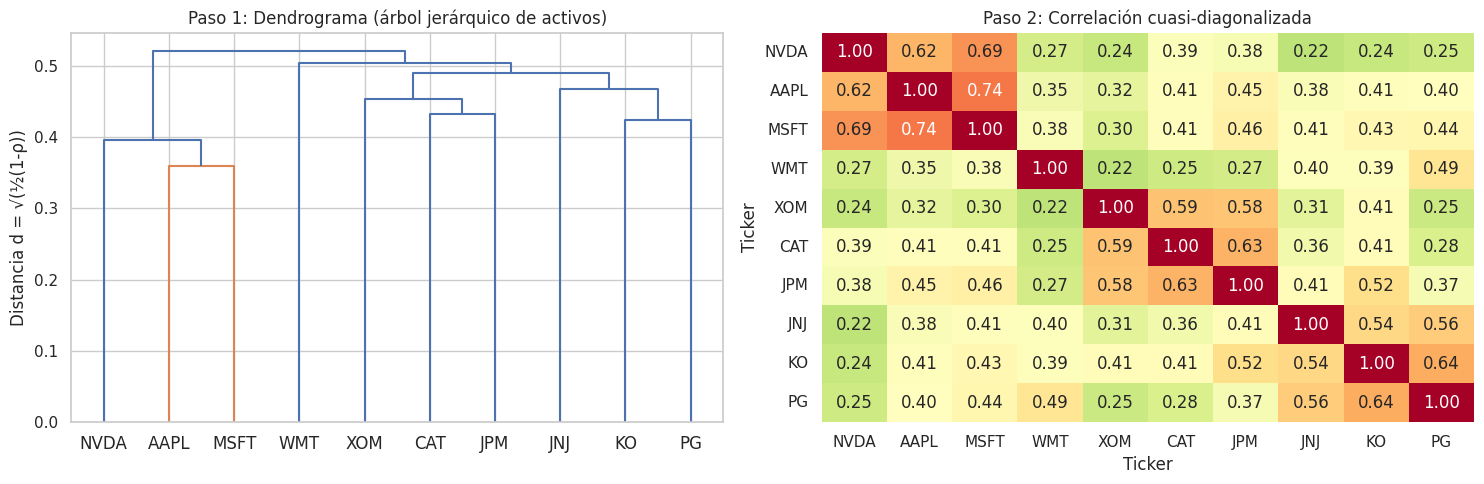

In [7]:
# ==========================================================
# HRP paso a paso
# ==========================================================
corr = ret_train.corr()
cov  = Sigma.copy()

# Paso 1: matriz de distancias y árbol jerárquico
dist = np.sqrt(0.5*(1 - corr))
Z = linkage(squareform(dist.values, checks=False), method="single")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
dendrogram(Z, labels=corr.columns.tolist(), ax=axes[0])
axes[0].set_title("Paso 1: Dendrograma (árbol jerárquico de activos)")
axes[0].set_ylabel("Distancia d = √(½(1-ρ))")

# Paso 2: cuasi-diagonalización
orden = leaves_list(Z)
tickers_ord = [corr.columns[i] for i in orden]
sns.heatmap(corr.loc[tickers_ord, tickers_ord], cmap="RdYlGn_r", ax=axes[1],
            annot=True, fmt=".2f", cbar=False, vmin=-0.2, vmax=1)
axes[1].set_title("Paso 2: Correlación cuasi-diagonalizada")
plt.tight_layout(); plt.show()

In [8]:
# Paso 3: bisección recursiva
def var_cluster(cov, items):
    sub = cov.loc[items, items].values
    ivp = 1/np.diag(sub); ivp /= ivp.sum()
    return ivp @ sub @ ivp

def hrp_pesos(cov, orden_tickers):
    w = pd.Series(1.0, index=orden_tickers)
    clusters = [orden_tickers]
    while clusters:
        nuevos = []
        for cl in clusters:
            if len(cl) <= 1:
                continue
            mitad = len(cl)//2
            c1, c2 = cl[:mitad], cl[mitad:]
            v1, v2 = var_cluster(cov, c1), var_cluster(cov, c2)
            alpha = 1 - v1/(v1+v2)
            w[c1] *= alpha
            w[c2] *= (1-alpha)
            nuevos += [c1, c2]
        clusters = nuevos
    return w

w_hrp = hrp_pesos(cov, tickers_ord).reindex(TICKERS).values
print("Pesos HRP:")
print(pd.Series(w_hrp, index=TICKERS).round(4).sort_values(ascending=False))

Pesos HRP:
JNJ     0.1983
WMT     0.1400
KO      0.1188
PG      0.1154
MSFT    0.0943
JPM     0.0875
AAPL    0.0755
CAT     0.0747
XOM     0.0677
NVDA    0.0280
dtype: float64


---
# 6. Benchmarks: Equal Weight y Risk Parity

**Equal Weight (1/N):** $w_i = 1/N$. DeMiguel et al. (2009) mostraron que es sorprendentemente difícil de vencer out-of-sample — el error de estimación de los métodos "óptimos" se come su ventaja teórica.

**Risk Parity (naive):** cada activo aporta el mismo riesgo. La **contribución de riesgo** del activo $i$ es

$$RC_i = w_i\,\frac{\partial \sigma_p}{\partial w_i} = \frac{w_i\,(\boldsymbol{\Sigma}\mathbf{w})_i}{\sigma_p}, \qquad \sum_i RC_i = \sigma_p$$

y se busca $RC_i = \sigma_p/N\;\forall i$. La versión simple (ignorando correlaciones) es varianza inversa: $w_i \propto 1/\sigma_i^2$.

,Markowitz Máx Sharpe,Mín Varianza (GMV),Black-Litterman,HRP (árbol),Risk Parity,Equal Weight
AAPL,2.74%,0.47%,17.28%,7.55%,7.90%,10.00%
MSFT,0.00%,1.52%,8.82%,9.43%,7.94%,10.00%
JNJ,0.00%,29.00%,8.83%,19.83%,13.37%,10.00%
PG,0.00%,0.00%,0.00%,11.54%,8.23%,10.00%
XOM,0.00%,21.15%,0.00%,6.77%,12.75%,10.00%
JPM,29.00%,0.43%,1.06%,8.75%,8.22%,10.00%
KO,34.86%,0.00%,2.90%,11.88%,5.61%,10.00%
NVDA,20.61%,15.90%,61.12%,2.80%,13.22%,10.00%
WMT,12.80%,24.60%,0.00%,14.00%,13.53%,10.00%
CAT,0.00%,6.94%,0.00%,7.47%,9.24%,10.00%


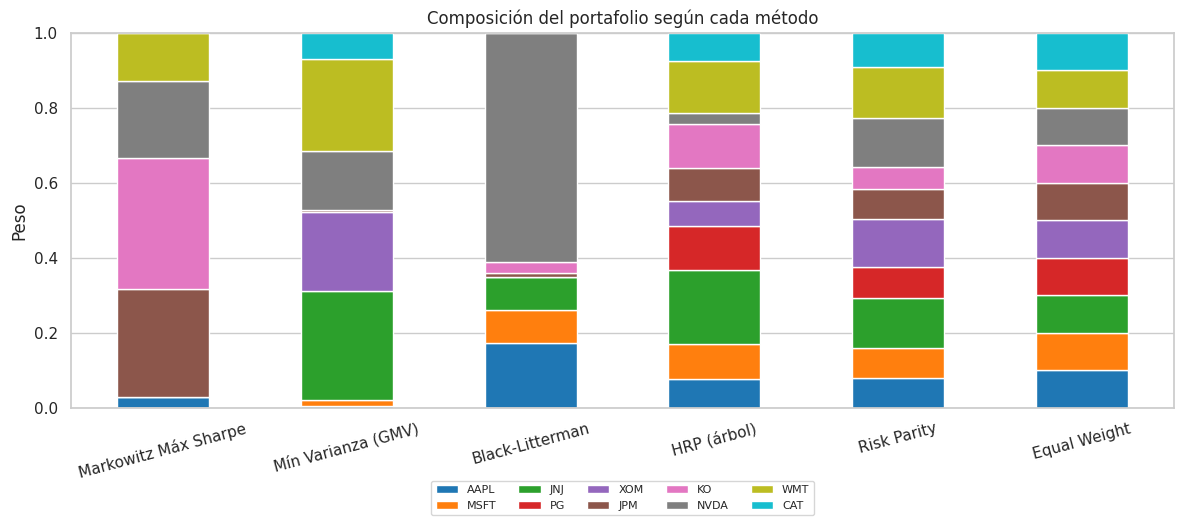


Concentración (1/N sería 0.100):
Equal Weight            0.100
Risk Parity             0.108
HRP (árbol)             0.120
Mín Varianza (GMV)      0.220
Markowitz Máx Sharpe    0.265
Black-Litterman         0.420
Name: Herfindahl (Σw²), dtype: float64


In [9]:
w_eq = np.ones(N)/N
w_iv = (1/np.diag(Sigma)); w_iv /= w_iv.sum()   # risk parity naive (varianza inversa)

# Risk parity completo: minimizar dispersión de contribuciones de riesgo
def rp_obj(w):
    sp = np.sqrt(w @ Sigma @ w)
    rc = w * (Sigma @ w) / sp
    return np.sum((rc - sp/N)**2)
w_rp = minimize(rp_obj, w0, bounds=[(0.001,1)]*N, constraints=cons).x

# ==========================================================
# Tabla y gráfica de pesos de TODOS los métodos
# ==========================================================
PESOS = pd.DataFrame({
    "Markowitz Máx Sharpe": w_tan, "Mín Varianza (GMV)": w_gmv,
    "Black-Litterman": w_bl, "HRP (árbol)": w_hrp,
    "Risk Parity": w_rp, "Equal Weight": w_eq}, index=TICKERS)

display(PESOS.round(4).style.background_gradient(cmap="Blues", axis=None).format("{:.2%}"))

PESOS.T.plot(kind="bar", stacked=True, figsize=(12, 5.5), colormap="tab10")
plt.title("Composición del portafolio según cada método")
plt.ylabel("Peso"); plt.legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5,-0.18))
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

# Concentración: índice de Herfindahl H = Σ w_i²  (menor = más diversificado)
herf = (PESOS**2).sum().rename("Herfindahl (Σw²)")
print("\nConcentración (1/N sería {:.3f}):".format(1/N))
print(herf.round(3).sort_values())

---
# 7. 🏁 Backtest out-of-sample y tabla comparativa final

Evaluamos cada portafolio con los pesos fijados **in-sample**, sobre los retornos del período de **test** que ningún método vio. Métricas:

- **Retorno anualizado:** $\hat\mu_p \cdot 252$ y **Volatilidad:** $\hat\sigma_p\sqrt{252}$
- **Sharpe:** $(\mu_p - r_f)/\sigma_p$
- **Máximo Drawdown:** $\;MDD = \min_t \left(\dfrac{V_t}{\max_{s\le t} V_s} - 1\right)$
- **VaR 95% diario (histórico):** percentil 5 de los retornos
- **Ratio de diversificación:** $DR = \dfrac{\sum_i w_i\sigma_i}{\sigma_p} \ge 1$ (cuánta volatilidad "desaparece" por correlaciones)

In [10]:
def backtest(w, rets):
    rp = rets @ w
    valor = (1+rp).cumprod()
    mu_a, sig_a = rp.mean()*252, rp.std()*np.sqrt(252)
    dd = (valor/valor.cummax() - 1).min()
    var95 = np.percentile(rp, 5)
    dr = (w @ np.sqrt(np.diag(Sigma))) / np.sqrt(w @ Sigma @ w)
    return valor, {"Retorno anual": mu_a, "Volatilidad": sig_a,
                   "Sharpe": (mu_a-rf)/sig_a, "Máx Drawdown": dd,
                   "VaR 95% diario": var95, "Ratio Diversif.": dr}

curvas, metricas = {}, {}
for nombre in PESOS.columns:
    curvas[nombre], metricas[nombre] = backtest(PESOS[nombre].values, ret_test)

TABLA = pd.DataFrame(metricas).T.sort_values("Sharpe", ascending=False)
display(TABLA.round(4).style
        .background_gradient(subset=["Sharpe","Retorno anual","Ratio Diversif."], cmap="Greens")
        .background_gradient(subset=["Volatilidad","Máx Drawdown"], cmap="Reds_r")
        .format({"Retorno anual":"{:.2%}","Volatilidad":"{:.2%}","Sharpe":"{:.2f}",
                 "Máx Drawdown":"{:.2%}","VaR 95% diario":"{:.2%}","Ratio Diversif.":"{:.2f}"}))

,Retorno anual,Volatilidad,Sharpe,Máx Drawdown,VaR 95% diario,Ratio Diversif.
HRP (árbol),24.38%,14.00%,1.53,-17.54%,-1.09%,1.46
Risk Parity,18.58%,12.06%,1.29,-14.86%,-0.98%,1.47
Equal Weight,20.37%,13.74%,1.26,-16.98%,-1.09%,1.45
Mín Varianza (GMV),16.80%,12.54%,1.10,-10.68%,-1.10%,1.35
Markowitz Máx Sharpe,20.94%,22.97%,0.78,-23.53%,-2.21%,1.22
Black-Litterman,5.59%,14.14%,0.18,-16.78%,-1.37%,1.29


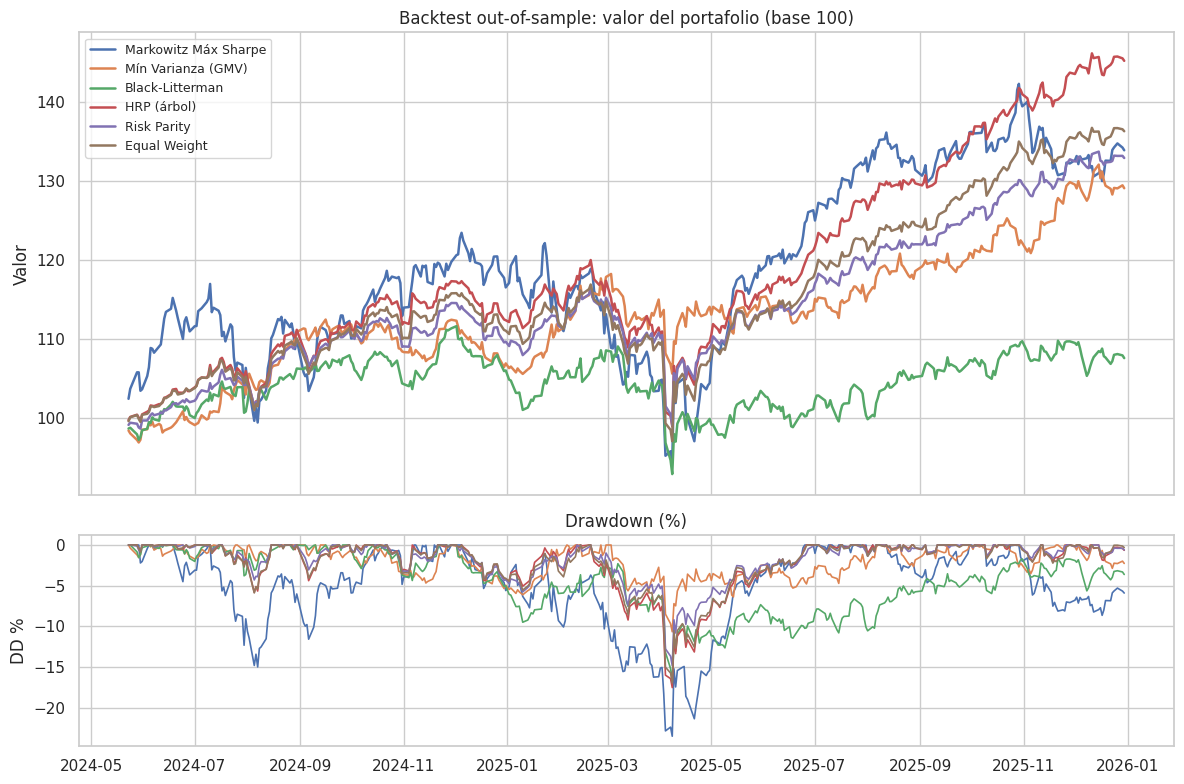

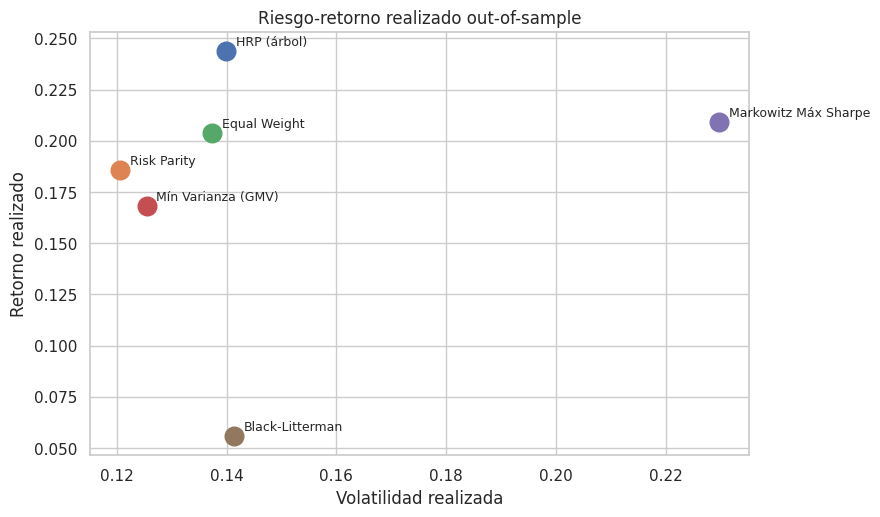

In [11]:
# Curvas de valor acumulado + drawdown
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios":[2.2,1]})
for nombre, v in curvas.items():
    axes[0].plot(v.index, v*100, lw=1.8, label=nombre)
    axes[1].plot(v.index, (v/v.cummax()-1)*100, lw=1.2)
axes[0].set_title("Backtest out-of-sample: valor del portafolio (base 100)")
axes[0].set_ylabel("Valor"); axes[0].legend(fontsize=9)
axes[1].set_title("Drawdown (%)"); axes[1].set_ylabel("DD %")
plt.tight_layout(); plt.show()

# Riesgo-retorno realizado
plt.figure(figsize=(8.5, 5.5))
for nombre in TABLA.index:
    plt.scatter(TABLA.loc[nombre,"Volatilidad"], TABLA.loc[nombre,"Retorno anual"], s=180)
    plt.annotate(nombre, (TABLA.loc[nombre,"Volatilidad"], TABLA.loc[nombre,"Retorno anual"]),
                 xytext=(7,4), textcoords="offset points", fontsize=9)
plt.xlabel("Volatilidad realizada"); plt.ylabel("Retorno realizado")
plt.title("Riesgo-retorno realizado out-of-sample"); plt.show()

## 8. Conclusiones y discusión para la clase

**Lo que típicamente se observa:**
- **Markowitz máx-Sharpe** brilla in-sample pero suele decepcionar out-of-sample: es un *error maximizer*, hipersensible a $\hat{\boldsymbol\mu}$.
- **GMV y Risk Parity** son más robustos: solo dependen de $\boldsymbol\Sigma$, que se estima mejor que $\boldsymbol\mu$.
- **Black-Litterman** produce pesos moderados y estables: se ancla al mercado y se desvía solo donde hay vistas. Es el estándar en gestión institucional.
- **HRP** logra diversificación robusta sin invertir $\boldsymbol\Sigma$ ni estimar $\boldsymbol\mu$ — el árbol jerárquico respeta la estructura de clusters (tecnología junta, defensivas juntas).
- **1/N** casi nunca es el peor: humildad estadística.

**Preguntas para discutir:**
1. ¿Por qué estimar $\boldsymbol{\mu}$ es mucho más difícil que estimar $\boldsymbol{\Sigma}$? (Pista: el error estándar de la media decrece con $\sqrt{T}$ del *horizonte*, no de la frecuencia de datos.)
2. ¿Qué pasa con la frontera eficiente si permitimos ventas en corto?
3. ¿Cómo cambiaría Black-Litterman si la vista sobre NVDA fuera muy incierta ($\Omega \to \infty$)?

**Extensiones sugeridas:**
- Rebalanceo mensual con ventana móvil (walk-forward) y costos de transacción.
- Shrinkage de covarianza (Ledoit-Wolf: `sklearn.covariance.LedoitWolf`).
- CVaR / Expected Shortfall como medida de riesgo en vez de varianza.
- HRP con enlace *ward* y comparar dendrogramas.

---
*Notebook educativo — Teoría de portafolios: Markowitz (1952), Black & Litterman (1992), López de Prado (2016).*